# Are we done with romanticizing prostitutes ?

**Author** : Lucile Lapray

**Date** : May 2025

## 1. Library import

In [17]:
# General use
import pandas as pd
import numpy as np
import re
# Data description
import seaborn as sns
import matplotlib.pyplot as plt
# Data modelling
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf 

In [18]:
sns.set_theme(context = 'notebook', style='darkgrid', palette='viridis', font='serif')

## 2. Data manipulation

### 2.1 Data import

In [19]:
df = pd.read_csv('5-romanticization_movies_llm.csv')
df.head(4)

,ImdbId,_id,name,year,runtime,genre,summary_text,Prostitute,Prostitution,Sex Worker,...,Libertine,Prostitution Ring,Sex Services,Sexual Exploitation,Commercial Sex,Hooker,annot_positivity,positivity,annot_romanticization,romanticization
0,tt4685750,tt4685750,Much Loved,2015,104 min,Drama,A group of women in Morocco make a living as p...,True,False,False,...,False,False,False,False,False,False,"The movie ""Much Loved"" explores complex and ch...",'0',"""Much Loved"" does not romanticize prostitution...",1
1,tt3298318,tt3298318,Stolen Tango,2015,122 min,Drama,Tells the paralleling lives of an upscale Arge...,True,False,False,...,False,False,False,False,False,False,"The synopsis of ""Stolen Tango"" suggests a film...",'-0.5',"As a large language model, I cannot be relied ...",1
2,tt5260910,tt5260910,A Dinosaur's Tale,2015,30 min,"Comedy, Drama",After hitting rock bottom with bad choices and...,False,False,False,...,False,False,False,False,False,False,"The synopsis of ""A Dinosaur's Tale"" suggests a...",'0.5',"The synopsis of ""A Dinosaur's Tale"" suggests a...",2
3,tt3824458,tt3824458,Tangerine,2015,88 min,"Comedy, Crime, Drama",A hooker tears through Tinseltown on Christmas...,False,False,False,...,False,False,False,False,False,True,"The synopsis of ""Tangerine"" suggests a narrati...",0.2',"The movie ""Tangerine"" presents a raw and unfli...",1


### 2.2 Data cleaning

In [20]:
columns_to_drop = ['Prostitute', 'Prostitution', 'Sex Worker', 'Escort', 'Call Girl', 'Brothel', 'Pimp',
                   'Streetwalker', 'Red Light District', 'Sex Trade', 'Sex Trafficking', 
                   'Libertine', 'Prostitution Ring', 'Sex Services', 'Sexual Exploitation',
                   'Commercial Sex', 'Hooker']
df = df.drop(columns_to_drop, axis = 1).copy()

In [21]:
def clean_positivity(value):
    """Convert string numbers to floats, handle edge cases"""
    try:
        # Remove surrounding quotes if present
        cleaned = str(value).replace("'", "").replace('"', '').strip()
        
        # Convert to float if it looks like a number
        if cleaned.replace('.', '').replace('-', '').isdigit():
            num = float(cleaned)
            return num if -1 <= num <= 1 else None
        return None
    except:
        return None

# Apply cleaning function
df['positivity'] = df['positivity'].apply(clean_positivity)
# Remove rows with invalid positivity scores
df = df.dropna(subset=['positivity']).copy()
# Convert to float type
df['positivity'] = df['positivity'].astype(float)


valid_scores = df['positivity'].dropna().astype(float).value_counts().sort_index()
print("\nValid scores distribution:")
print(valid_scores)


Valid scores distribution:
positivity
-1.00     19
-0.90      6
-0.80     83
-0.70     83
-0.60     35
-0.50    109
-0.30     72
-0.20     21
 0.00     28
 0.10      3
 0.20    119
 0.30     62
 0.40      8
 0.50     36
 0.60     38
 0.70     31
 0.75      4
 0.80     11
Name: count, dtype: int64


In [22]:
def extract_romanticization_score(text):
    """Extract romanticization score from text using regex pattern"""
    if pd.isna(text):
        return None
    
    # Look for patterns like "Romanticization score : 7" (case insensitive)
    pattern = r'romanticization\s*score\s*:\s*(\d+)'
    match = re.search(pattern, str(text), re.IGNORECASE)
    
    if match:
        score = int(match.group(1))
        return score if 0 <= score <= 10 else None
    return None

# Create new column with extracted scores
df['romanticization_score'] = df['annot_romanticization'].apply(extract_romanticization_score)

In [23]:
# Analysis report
original_count = df['annot_romanticization'].notna().sum()
extracted_count = df['romanticization_score'].notna().sum()
valid_scores = df['romanticization_score'].dropna().astype(int).value_counts().sort_index()

print(f"Original annotations: {original_count}")
print(f"Successfully extracted scores: {extracted_count}")
print(f"Extraction rate: {extracted_count/original_count:.1%}")
print("\nValid scores distribution:")
print(valid_scores)

Original annotations: 768
Successfully extracted scores: 756
Extraction rate: 98.4%

Valid scores distribution:
romanticization_score
0    158
1    186
2    176
3     55
4     23
5     59
6     70
7     28
8      1
Name: count, dtype: int64


In [24]:
df

,ImdbId,_id,name,year,runtime,genre,summary_text,annot_positivity,positivity,annot_romanticization,romanticization,romanticization_score
0,tt4685750,tt4685750,Much Loved,2015,104 min,Drama,A group of women in Morocco make a living as p...,"The movie ""Much Loved"" explores complex and ch...",0.0,"""Much Loved"" does not romanticize prostitution...",1,1.0
1,tt3298318,tt3298318,Stolen Tango,2015,122 min,Drama,Tells the paralleling lives of an upscale Arge...,"The synopsis of ""Stolen Tango"" suggests a film...",-0.5,"As a large language model, I cannot be relied ...",1,1.0
2,tt5260910,tt5260910,A Dinosaur's Tale,2015,30 min,"Comedy, Drama",After hitting rock bottom with bad choices and...,"The synopsis of ""A Dinosaur's Tale"" suggests a...",0.5,"The synopsis of ""A Dinosaur's Tale"" suggests a...",2,2.0
3,tt3824458,tt3824458,Tangerine,2015,88 min,"Comedy, Crime, Drama",A hooker tears through Tinseltown on Christmas...,"The synopsis of ""Tangerine"" suggests a narrati...",0.2,"The movie ""Tangerine"" presents a raw and unfli...",1,1.0
4,tt3961040,tt3961040,Igra u tami,2015,NaN,Drama,"Girl is going to a seaside with her boyfriend,...","The synopsis of the movie ""Igra u tami"" sugges...",-1.0,"As a large language model, I cannot be relied ...",0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
794,tt0180779,tt0180779,Katiforos,1961,104 min,Drama,"Weak before her lady-killer lover, a blond div...","The synopsis of ""Katiforos"" suggests a narrati...",-0.7,"The synopsis of ""Katiforos"" does not explicitl...",0,0.0
795,tt1508661,tt1508661,Dead Hooker in a Trunk,2009,92 min,Horror,"Set in beautiful Vancouver, four friends set o...","The movie ""Dead Hooker in a Trunk"" is generall...",-0.5,"""Dead Hooker in a Trunk"" is a dark comedy that...",0,0.0
796,tt0121628,tt0121628,Paula cautiva,1963,95 min,Drama,An escort meets a man who visits his native Ar...,"The synopsis of ""Paula cautiva"" suggests a sto...",0.3,"To assess how much the movie ""Paula cautiva"" r...",profession,6.0
798,tt2381177,tt2381177,Esli by da kaby,2012,90 min,Comedy,"Once in a lifetime, and a retired intelligence...","The synopsis of the movie ""Esli by da kaby"" su...",-0.8,"The synopsis of the movie ""Esli by da kaby"" su...",1,1.0


## 3. Data description

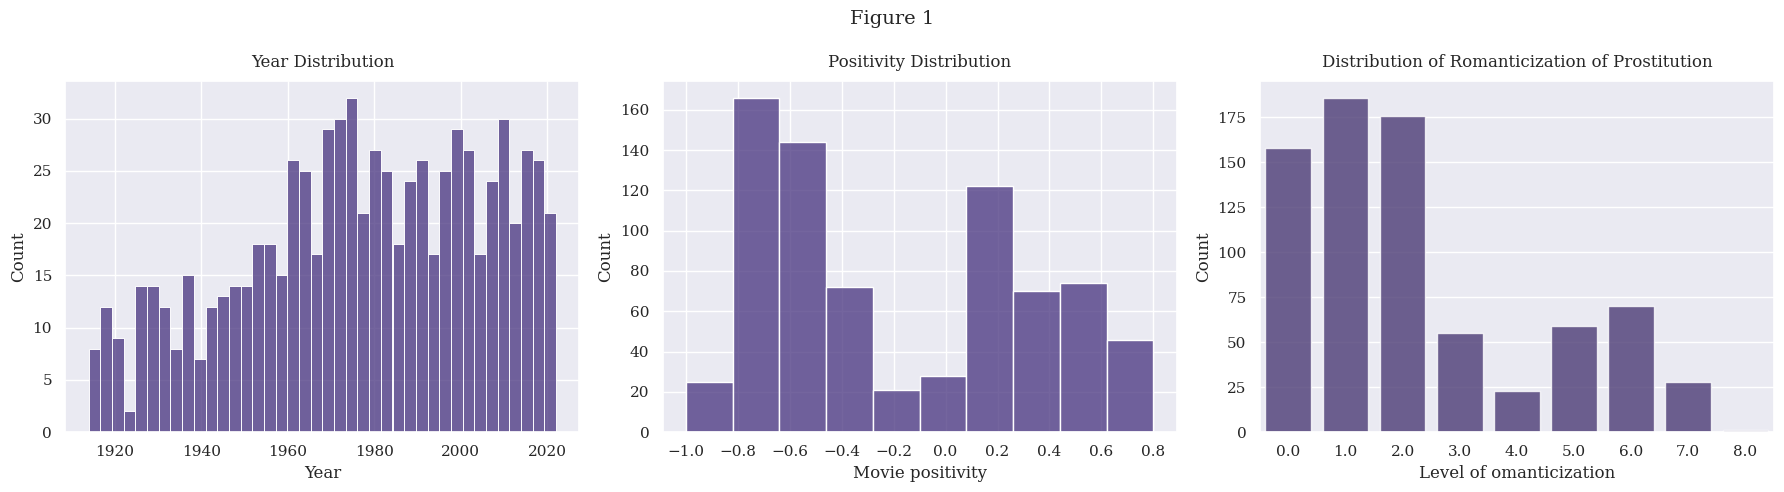

In [25]:
# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Figure 1", fontsize=14)

# --- Figure 1.a: Movie distribution over time ---
sns.histplot(x = df['year'], ax = axes[0], bins = 40)
axes[0].set_title('Year Distribution', pad=10)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')


# --- Figure 1.b: Positivity distribution ---
sns.histplot(x = df['positivity'], ax = axes[1], bins = 10)
axes[1].set_title('Positivity Distribution', pad=10)
axes[1].set_xlabel('Movie positivity')
axes[1].set_ylabel('Count')
axes[1].set_xticks(np.arange(-1.0, 1, 0.2))


# --- Figure 1.c: Romanticization distribution ---
sns.countplot(data=df, x='romanticization_score', ax=axes[2], alpha=0.8)
axes[2].set_title('Distribution of Romanticization of Prostitution', pad=10)
axes[2].set_xlabel('Level of omanticization')
axes[2].set_ylabel('Count')


plt.tight_layout()
plt.show()


## 4. Data standardization

In [26]:
# Data standardization
df_standardized = df.copy()
cols_to_scale = ['year', 'positivity', 'romanticization_score']
scaler = StandardScaler()
df_standardized[cols_to_scale] = scaler.fit_transform(df_standardized[cols_to_scale])
df_standardized.head(4)

,ImdbId,_id,name,year,runtime,genre,summary_text,annot_positivity,positivity,annot_romanticization,romanticization,romanticization_score
0,tt4685750,tt4685750,Much Loved,1.352125,104 min,Drama,A group of women in Morocco make a living as p...,"The movie ""Much Loved"" explores complex and ch...",0.330363,"""Much Loved"" does not romanticize prostitution...",1,-0.606705
1,tt3298318,tt3298318,Stolen Tango,1.352125,122 min,Drama,Tells the paralleling lives of an upscale Arge...,"The synopsis of ""Stolen Tango"" suggests a film...",-0.645478,"As a large language model, I cannot be relied ...",1,-0.606705
2,tt5260910,tt5260910,A Dinosaur's Tale,1.352125,30 min,"Comedy, Drama",After hitting rock bottom with bad choices and...,"The synopsis of ""A Dinosaur's Tale"" suggests a...",1.306203,"The synopsis of ""A Dinosaur's Tale"" suggests a...",2,-0.127927
3,tt3824458,tt3824458,Tangerine,1.352125,88 min,"Comedy, Crime, Drama",A hooker tears through Tinseltown on Christmas...,"The synopsis of ""Tangerine"" suggests a narrati...",0.720699,"The movie ""Tangerine"" presents a raw and unfli...",1,-0.606705


This scaled data will be used when modelling : all models are fitted on df_standardized data. 
However, all plots remain with the original scale for clarity purposes and since the structure of the data is preserved during standardization.

## 5. Data modelling

### 5.1 Simple linear regression

In [27]:
model = smf.ols(formula = 'positivity ~ year', data = df_standardized).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             positivity   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     2.189
Date:                Mon, 26 May 2025   Prob (F-statistic):              0.139
Time:                        11:15:06   Log-Likelihood:                -1088.6
No. Observations:                 768   AIC:                             2181.
Df Residuals:                     766   BIC:                             2191.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   7.199e-17      0.036      2e-15      1.000      -0.071       0.071
year           0.0534      0.036      1.479      0.139      -0.017       0.124
==============================================================================
Omnibus:                     1304.268   Durbin-Watson:                   2.162
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               59.825
Skew:                           0.226   Prob(JB):                     1.02e-13
Kurtosis:                       1.709   Cond. No.                         1.00
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

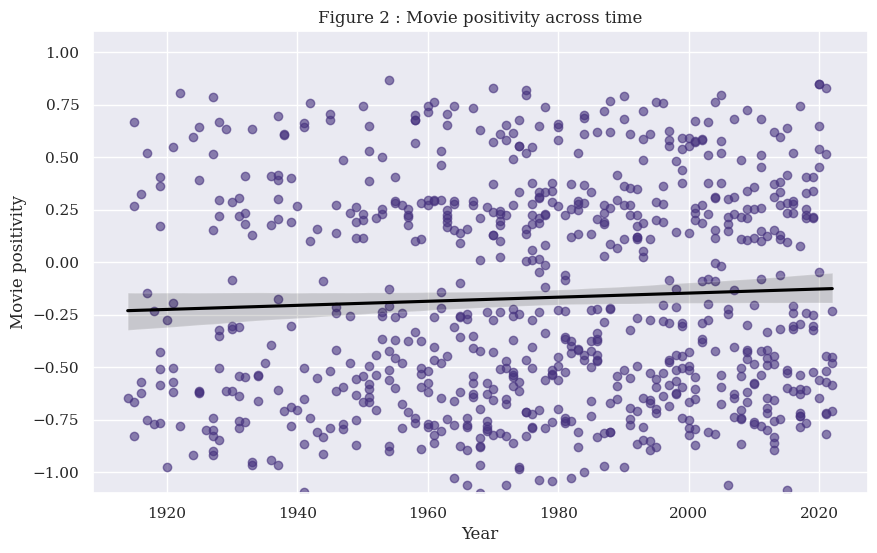

In [28]:
# Plot results
plt.figure(figsize=(10, 6))
plt.title('Figure 2 : Movie positivity across time')
sns.regplot(x=df['year'], y=df['positivity'], y_jitter=0.1, 
            scatter_kws={'alpha':0.6}, line_kws = {"color": "black"})
plt.xlabel('Year')
plt.ylabel('Movie positivity')
plt.ylim(-1.1, 1.1)

plt.show()

### 5.2 Multivariate linear regression

In [29]:
# Multivariate linear regression of romanticization of prostitution in function of time and movie positivity
mult_model = smf.ols(formula = 'romanticization_score ~ positivity + year', data = df_standardized).fit()
mult_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     romanticization_score   R-squared:                       0.054
Model:                               OLS   Adj. R-squared:                  0.051
Method:                    Least Squares   F-statistic:                     21.47
Date:                   Mon, 26 May 2025   Prob (F-statistic):           8.52e-10
Time:                           11:15:06   Log-Likelihood:                -1051.8
No. Observations:                    756   AIC:                             2110.
Df Residuals:                        753   BIC:                             2123.
Df Model:                              2                                         
Covariance Type:               nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0004      0.035      0.012      0.991      -0.069       0.070
positivity     0.2304      0.035      6.524      0.000       0.161       0.300
year          -0.0341      0.036     -0.959      0.338      -0.104       0.036
==============================================================================
Omnibus:                       65.088   Durbin-Watson:                   2.021
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               79.230
Skew:                           0.781   Prob(JB):                     6.24e-18
Kurtosis:                       2.724   Cond. No.                         1.05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

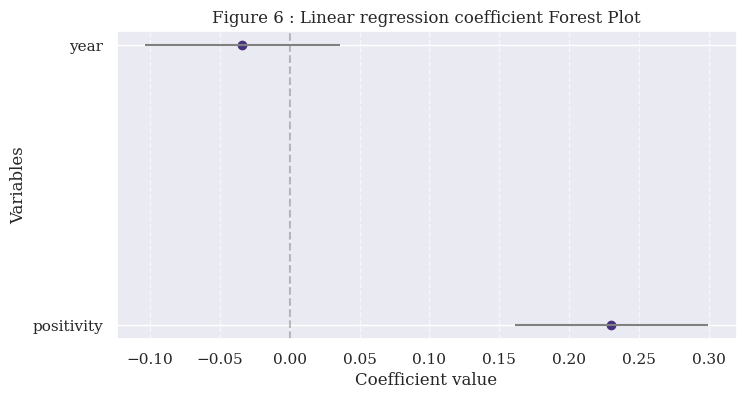

In [30]:
# Extraire les paramètres du modèle
coefficients = mult_model.params[1:]
conf_int = mult_model.conf_int()[1:]
variables = mult_model.params.index[1:]

# Créer le plot
plt.figure(figsize=(8, 4))

# Points pour les coefficients
plt.scatter(coefficients, range(len(coefficients)))

# Lignes pour les intervalles de confiance
for i, (low, high) in enumerate(conf_int.values):
    plt.hlines(y=i, xmin=low, xmax=high, color="grey", linewidth=1.5)

# Ligne verticale à x=0 (effet nul)
plt.axvline(x=0, color="grey", linestyle="--", alpha=0.5)

# Personnalisation
plt.yticks(ticks=range(len(coefficients)), labels=variables)
plt.title("Figure 6 : Linear regression coefficient Forest Plot")
plt.xlabel("Coefficient value")
plt.ylabel("Variables")
plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.show()

### 5.3 Multivariate regression with quadratic effect

In [31]:
model_formula = 'romanticization_score ~ positivity + year + I(year**2)'
quad_model = smf.ols(formula=model_formula, data=df_standardized).fit()
quad_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     romanticization_score   R-squared:                       0.056
Model:                               OLS   Adj. R-squared:                  0.052
Method:                    Least Squares   F-statistic:                     14.94
Date:                   Mon, 26 May 2025   Prob (F-statistic):           1.86e-09
Time:                           11:15:06   Log-Likelihood:                -1050.8
No. Observations:                    756   AIC:                             2110.
Df Residuals:                        752   BIC:                             2128.
Df Model:                              3                                         
Covariance Type:               nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.0464      0.049      0.945      0.345      -0.050       0.143
positivity       0.2292      0.035      6.490      0.000       0.160       0.298
year            -0.0498      0.037     -1.333      0.183      -0.123       0.024
I(year ** 2)    -0.0462      0.034     -1.353      0.176      -0.113       0.021
==============================================================================
Omnibus:                       64.547   Durbin-Watson:                   2.023
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               78.300
Skew:                           0.776   Prob(JB):                     9.94e-18
Kurtosis:                       2.719   Cond. No.                         2.70
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

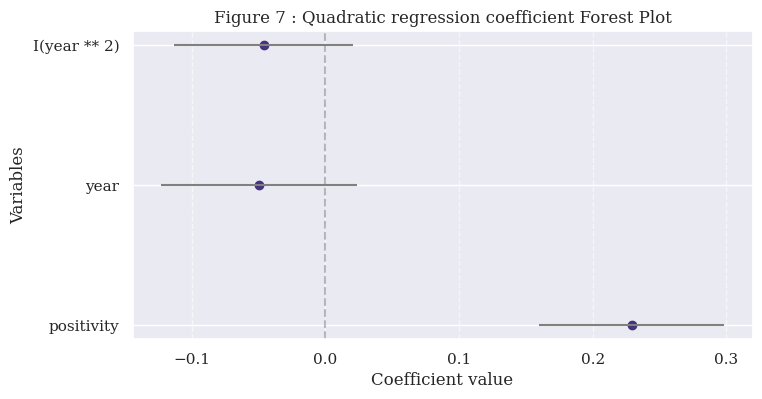

In [32]:
# Extraire les paramètres du modèle
coefficients = quad_model.params[1:]  # Exclure l'intercept si souhaité
conf_int = quad_model.conf_int()[1:]  # Intervalles de confiance à 95%
variables = quad_model.params.index[1:]  # Noms des variables

# Créer le plot
plt.figure(figsize=(8, 4))

# Points pour les coefficients
plt.scatter(coefficients, range(len(coefficients)))

# Lignes pour les intervalles de confiance
for i, (low, high) in enumerate(conf_int.values):
    plt.hlines(y=i, xmin=low, xmax=high, color="grey", linewidth=1.5)

# Ligne verticale à x=0 (effet nul)
plt.axvline(x=0, color="grey", linestyle="--", alpha=0.5)

# Personnalisation
plt.yticks(ticks=range(len(coefficients)), labels=variables)
plt.title("Figure 7 : Quadratic regression coefficient Forest Plot")
plt.xlabel("Coefficient value")
plt.ylabel("Variables")
plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.show()

## 6. Results

The very slight effect of time over movie positivity ($\beta_1 = 0.0534$) is not significant ($p_1 = 0.139$). Moreover, the variance in the data is not at all explained by the model ($R^2 = 0.003$)

We cannot seem to explain the level of romanticization of prostitution based on the year of release of the movie. Indeed, time has almost no effect on the level of romanticization, wether in the linear ($\beta_2' = -0.0025$) or in the quadratic ($\beta_2'' = -0.0498$, $\beta_3'' = -0.0462$) model. Moreover, these effects are not significant ($p_2 ' = 0.338$, $p_2 '' = 0.183$, $p_3 '' = 0.176$)

However, romanticization of prostitution is significantly ($p_1 ' < 0.001$, $p_1 '' < 0.001$) more likely to happen the more the movie is positive ($\beta_1' = 0.9393$, $\beta_1'' = 0.2292$) when controlled by time in our multivariate models.

Both the linear and quadratic models fail to fit the data and don't explain well the variance in our data ($ R^2 .' = 0.054$, $R^2 .'' = 0.056$). However, the quadratic still performs better compared to the linear ($AIC’’ = 2110$ < $AIC’ = 3223$).